A comment on data formatting:
- data arrays should take the form $[x(t_1), x(t_2), ..., x(t_n)]$
- thus, arrays should have the form (rows, cols) == (n_state_vars, n_samples)
    - so, x[0] should be many samples of the first state variable
    - note the syntax "np.array([row1, row2, ...])"

In [9]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


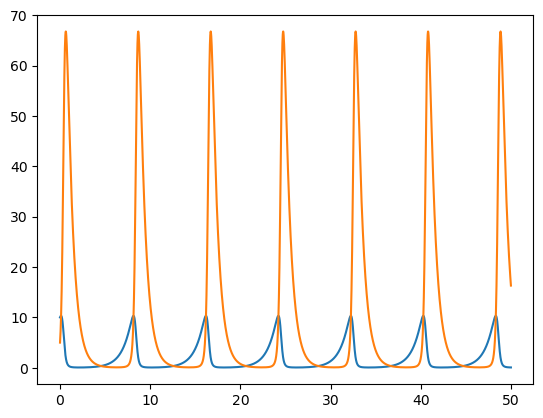

In [10]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

dt_train = 0.01
t_span_train = (0, 50)

t_eval_train = np.arange(t_span_train[0], t_span_train[1] + dt_train, dt_train)
x0_train = (10, 5)
x_train = generate_training_data(lotka_volterra_rhs, x0_train, t_eval_train)

plt.plot(t_eval_train, x_train.T)
plt.show()

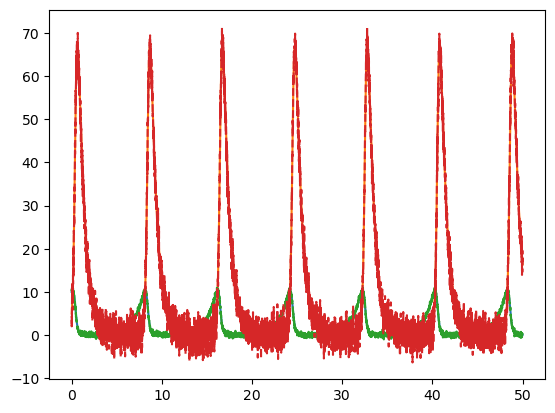

In [11]:
x_train_noisy = add_noise_to_data(x_train, 0.1)
plt.plot(t_eval_train, x_train.T)
plt.plot(t_eval_train, x_train_noisy.T, '--')
plt.show()

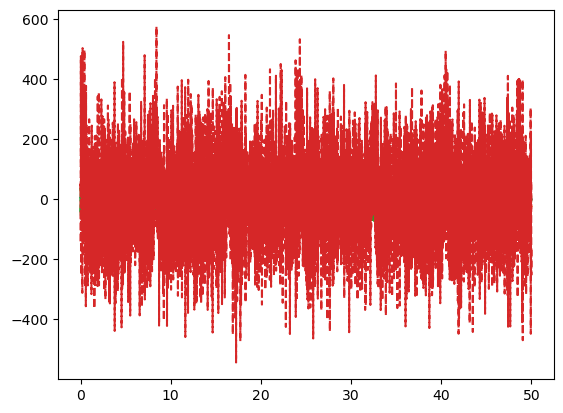

In [12]:
# generate the true derivative
x_dot_true = lotka_volterra_rhs(t_eval_train, x_train)

# x_dot_approx = dxdt(x_train_noisy, t_train, kind="savitzky_golay", left=.5, right=.5, order=3)
x_dot_approx = dxdt(x_train_noisy, t_eval_train, kind="finite_difference", k=1)

plt.plot(t_eval_train, x_dot_true.T)
plt.plot(t_eval_train, x_dot_approx.T, '--')
plt.show()

In [13]:
threshold = 0.05 # NOTE: was 0.5 in demo notebook

noise_levels = [0, 1e-4, 1e-3, 1e-2, 1e-1, 1]

models = []
ps_models = []
for noise_level in tqdm(noise_levels):
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    
    # generate the derivative of the noisy data
    # NOTE: we can change the kind of derivative and the parameters of the derivative method!
    x_dot_approx = dxdt(x_train_noisy, t_eval_train, kind="finite_difference", k=1)

    # create and fit a SINDy model
    model = SINDyModel(threshold)
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)

    import pysindy as ps
    ps_model = ps.SINDy(optimizer=ps.STLSQ(threshold=threshold), feature_library=ps.PolynomialLibrary(degree=5))
    ps_model.fit(x_train_noisy.T, x_dot=x_dot_approx.T)
    ps_models.append(ps_model)


# print the models
for i in range(len(noise_levels)):
    print(f"noise level: {noise_levels[i]}")
    models[i].print(decimals=3)
    ps_models[i].print()
    print()

100%|██████████| 6/6 [00:01<00:00,  3.65it/s]

noise level: 0
x1 dot = + 1.000 x0^1 + -0.100 x0^1 x1^1 
x2 dot = + -1.500 x1^1 + 0.750 x0^1 x1^1 
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = 0.227 1

noise level: 0.0001
x1 dot = + 1.000 x0^1 + -0.100 x0^1 x1^1 
x2 dot = + -1.500 x1^1 + 0.750 x0^1 x1^1 
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.750 x0 x1

noise level: 0.001
x1 dot = + 1.000 x0^1 + -0.100 x0^1 x1^1 
x2 dot = + -1.500 x1^1 + 0.750 x0^1 x1^1 
(x0)' = 1.000 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.750 x0 x1

noise level: 0.01
x1 dot = + 0.998 x0^1 + -0.100 x0^1 x1^1 
x2 dot = + -1.500 x1^1 + 0.751 x0^1 x1^1 
(x0)' = 0.998 x0 + -0.100 x0 x1
(x1)' = -1.500 x1 + 0.751 x0 x1

noise level: 0.1
x1 dot = + 2.128 1 + -0.198 x1^1 + -0.088 x0^1 
x2 dot = + -1.469 x1^1 + 0.131 x0^1 + 0.734 x0^1 x1^1 
(x0)' = 2.128 1 + -0.088 x0 + -0.198 x1
(x1)' = 0.131 x0 + -1.469 x1 + 0.734 x0 x1

noise level: 1
x1 dot = + 0.313 1 + -0.117 x1^1 + -0.523 x0^1 + 0.064 x0^2 
x2 dot = + -11.991 1 + 3.472 x0^1 + 0.201 x0^2 
(x0)' = 0.313 1 + -0

In [14]:
dt_pred = 0.01
t_span_pred = (0, 50)

t_eval_pred = np.arange(t_span_train[0], t_span_train[1] + dt_train, dt_train)
x0_pred = (10, 5)

x_preds = []
for model in tqdm(models):
    x_pred = generate_model_prediction(model, x0_pred, t_eval_pred)
    x_preds.append(x_pred)

100%|██████████| 6/6 [00:15<00:00,  2.59s/it]


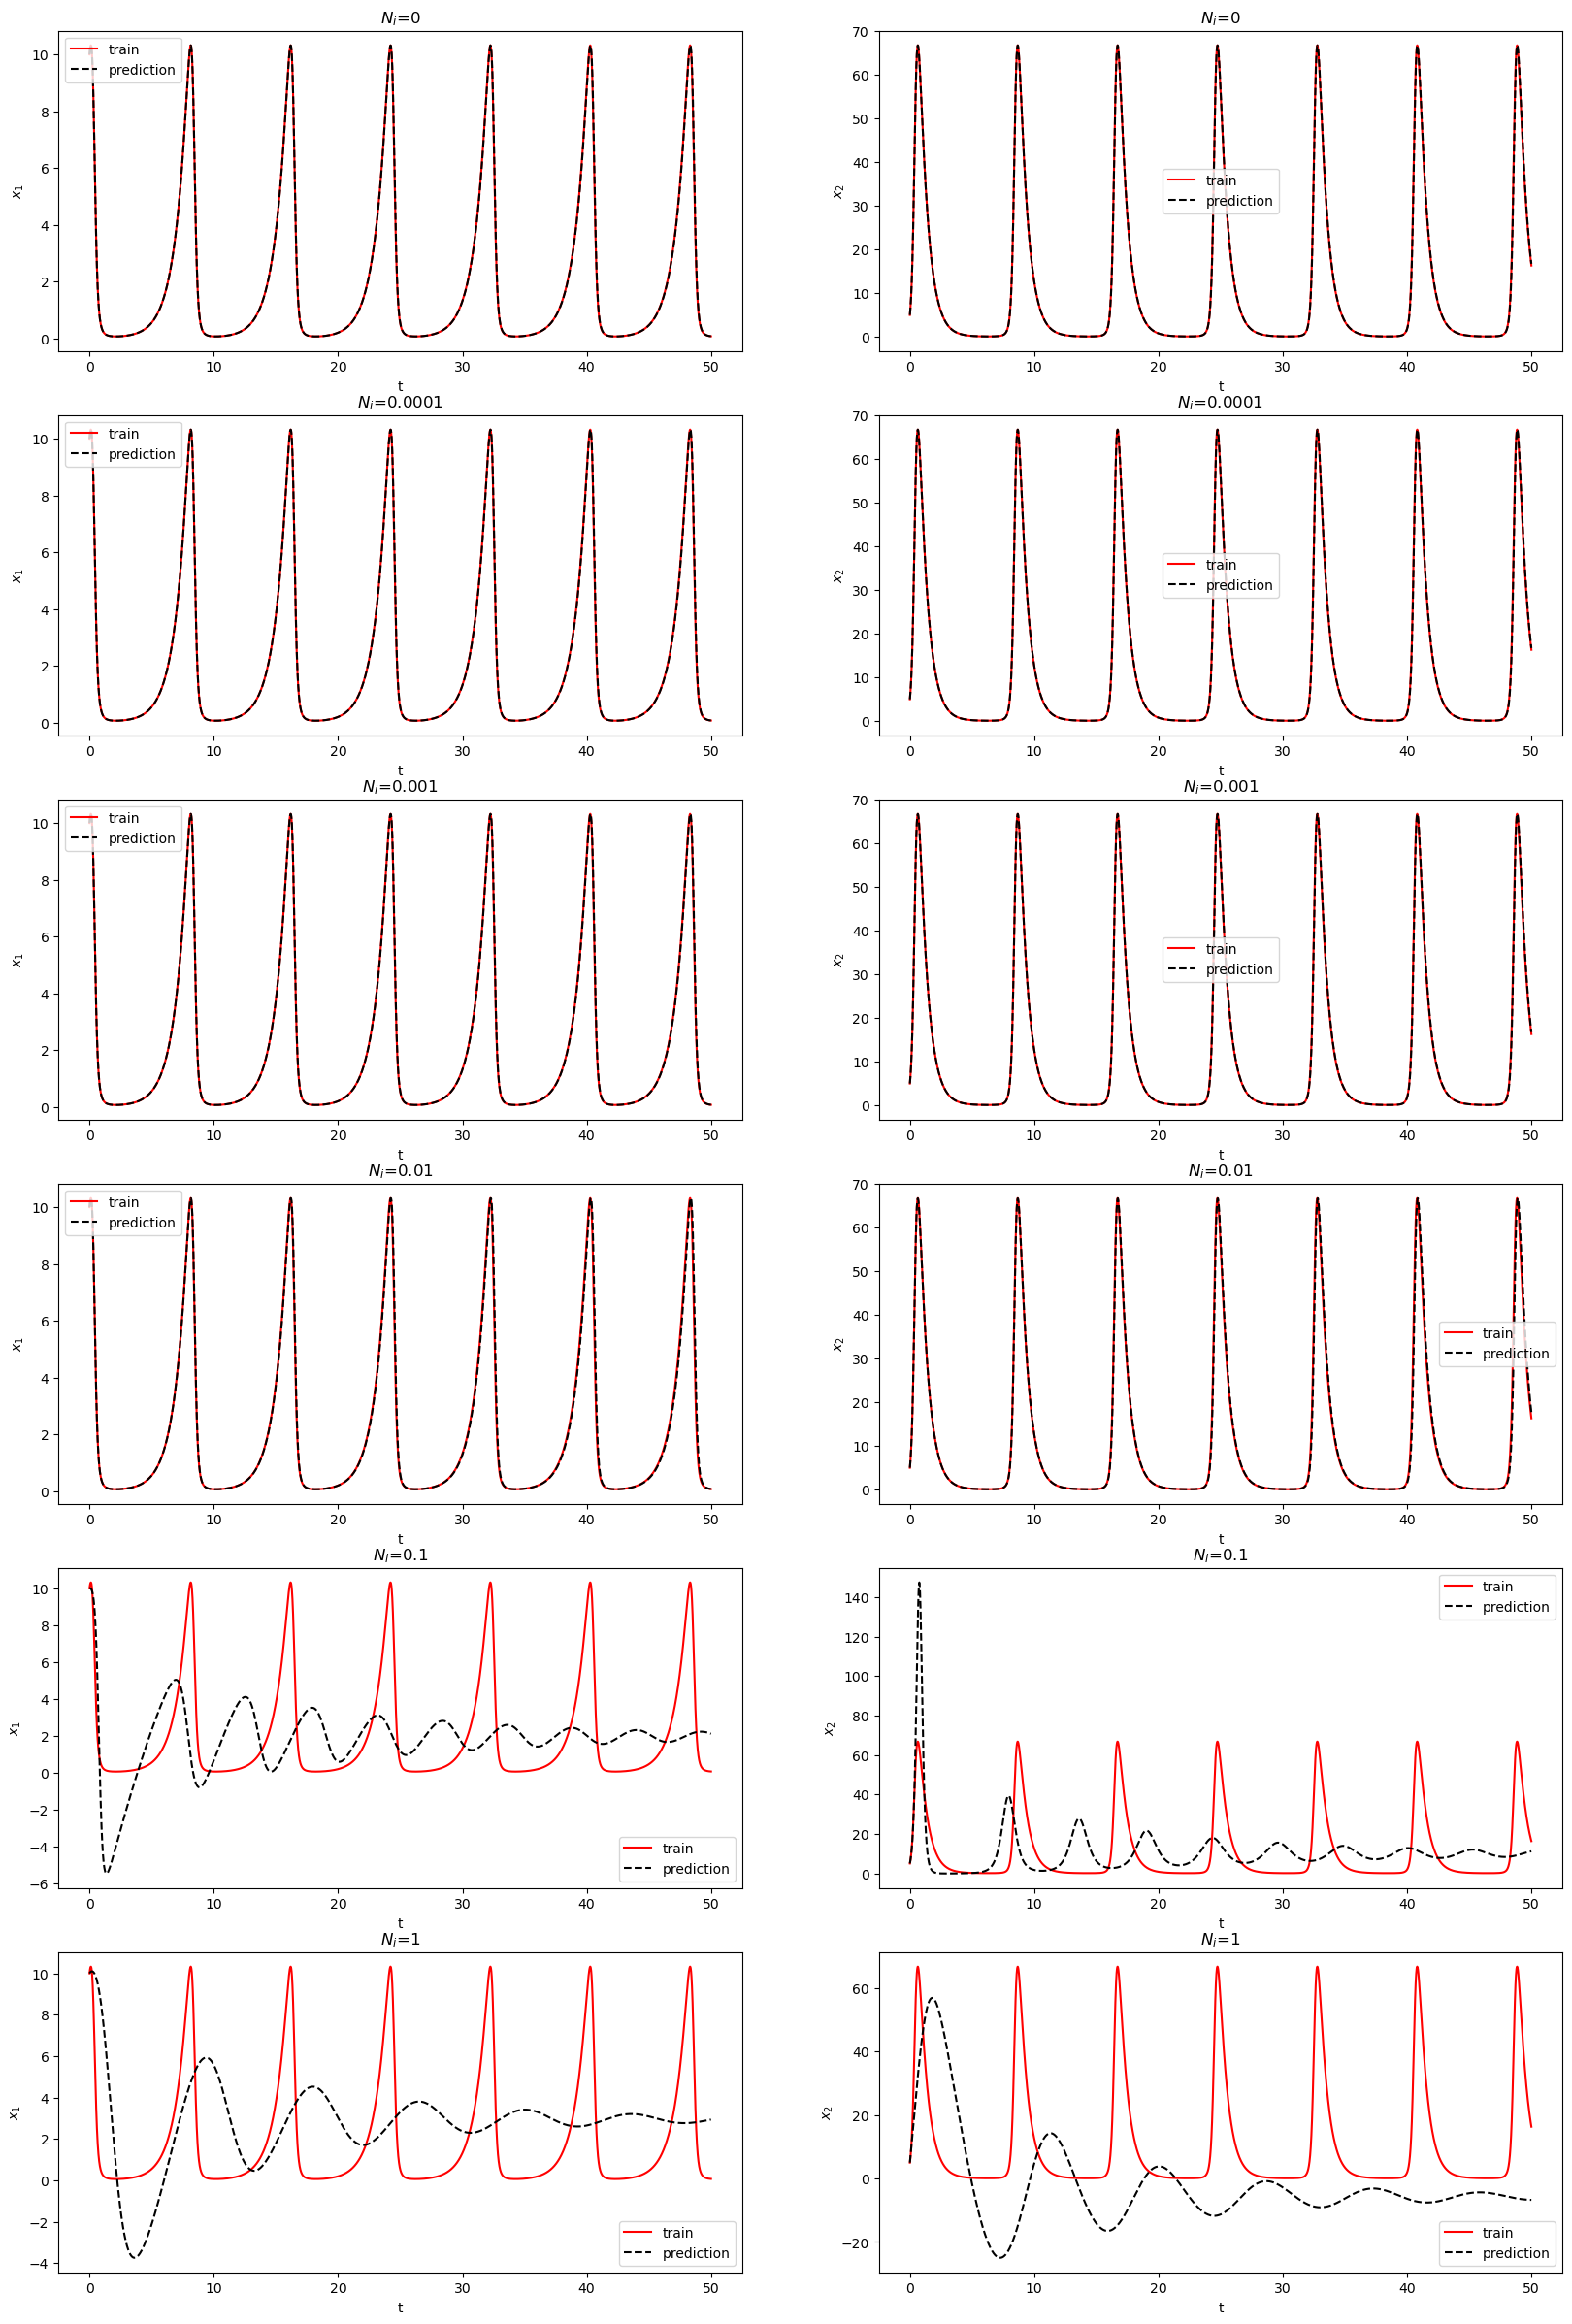

In [15]:
n_rows = len(noise_levels)
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 5*n_rows))

for row in range(n_rows):
    # each row corresponds to a different noise level

    for col in range(n_cols):
        # plot the col'th training state variable
        axs[row, col].plot(t_eval_train, x_train[col], "r", label="train")
        
        # plot the col'th state variable model prediction
        axs[row, col].plot(t_eval_pred, x_preds[row][col], "k--", label="prediction")

        # set the title and labels
        axs[row, col].set_title(f"$N_i$={noise_levels[row]}")
        axs[row, col].set_xlabel("t")
        axs[row, col].set_ylabel(f"$x_{col + 1}$")
        axs[row, col].legend()

fig.show()

In [16]:
for i in range(len(noise_levels)):
    rte = relative_trajectory_error(x_train, x_preds[i])
    print(f"noise level: {noise_levels[i]:.6f}, relative trajectory error: {rte:.6f}")

noise level: 0.000000, relative trajectory error: 0.000295
noise level: 0.000100, relative trajectory error: 0.000303
noise level: 0.001000, relative trajectory error: 0.000384
noise level: 0.010000, relative trajectory error: 0.003275
noise level: 0.100000, relative trajectory error: 0.825670
noise level: 1.000000, relative trajectory error: 1.558883
